<a href="https://colab.research.google.com/github/BeaLagayada/CS-ELECTIVE-1-ASSIGNMENT/blob/main/LAGAYADA_Act1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



################ PROBLEM 1 ################

Problem 1(a): x^3 = 9
Interval: (0, 3)
Decimal places: 6
Root = 2.080083
 Iteration        a        b  Midpoint   f(midpoint)        Error
         1 0.000000 3.000000  1.500000 -5.625000e+00 1.500000e+00
         2 1.500000 3.000000  2.250000  2.390625e+00 7.500000e-01
         3 1.500000 2.250000  1.875000 -2.408203e+00 3.750000e-01
         4 1.875000 2.250000  2.062500 -2.263184e-01 1.875000e-01
         5 2.062500 2.250000  2.156250  1.025299e+00 9.375000e-02
         6 2.062500 2.156250  2.109375  3.855858e-01 4.687500e-02
         7 2.062500 2.109375  2.085938  7.619619e-02 2.343750e-02
         8 2.062500 2.085938  2.074219 -7.591563e-02 1.171875e-02
         9 2.074219 2.085938  2.080078 -7.396191e-05 5.859375e-03
        10 2.080078 2.085938  2.083008  3.800748e-02 2.929688e-03
        11 2.080078 2.083008  2.081543  1.895336e-02 1.464844e-03
        12 2.080078 2.081543  2.080811  9.436350e-03 7.324219e-04
        13 2.080078 2.

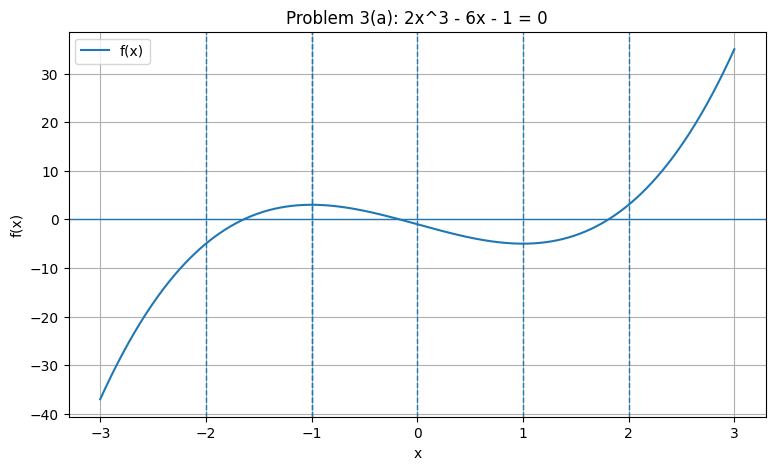


Problem 3(a) Roots:
Interval (-2, -1): root = -1.641783
Interval (-1, 0): root = -0.168254
Interval (1, 2): root = 1.810038


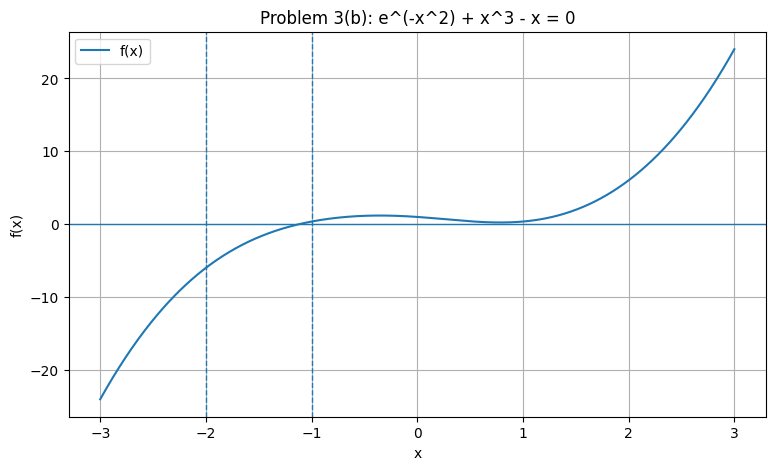


Problem 3(b) Root:
Interval (-2, -1): root = -1.120094


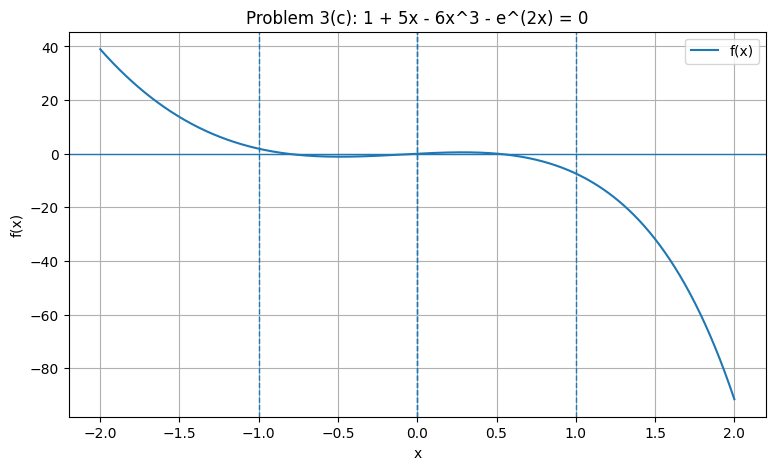


Problem 3(c) Roots:
Interval (-1, 0): root = 0.000000
Interval (0, 1): root = 0.000000


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BISECTION METHOD
# ============================================================

def bisection(f, a, b, decimal_places=6):
    """
    Finds a root of f(x) using the Bisection Method.
    The result is accurate to the requested decimal places.
    """

    if f(a) == 0:
        return a, []
    if f(b) == 0:
        return b, []

    if f(a) * f(b) > 0:
        raise ValueError("The interval does not contain a sign change.")

    tolerance = 0.5 * 10 ** (-decimal_places)
    records = []
    iteration = 1

    while (b - a) / 2 > tolerance:
        midpoint = (a + b) / 2
        f_mid = f(midpoint)

        records.append([
            iteration,
            a,
            b,
            midpoint,
            f_mid,
            (b - a) / 2
        ])

        if f_mid == 0:
            a = b = midpoint
            break
        elif f(a) * f_mid < 0:
            b = midpoint
        else:
            a = midpoint

        iteration += 1

    root = (a + b) / 2
    return root, records


def show_result(title, f, interval, decimal_places=6):
    """Run Bisection Method and display the iteration table."""

    root, records = bisection(
        f,
        interval[0],
        interval[1],
        decimal_places
    )

    print("\n" + "=" * 70)
    print(title)
    print("Interval:", interval)
    print("Decimal places:", decimal_places)
    print("Root =", f"{root:.{decimal_places}f}")
    print("=" * 70)

    if records:
        table = pd.DataFrame(
            records,
            columns=[
                "Iteration",
                "a",
                "b",
                "Midpoint",
                "f(midpoint)",
                "Error"
            ]
        )

        print(table.to_string(index=False))


# ============================================================
# PROBLEM 1
# Find roots to SIX correct decimal places
# ============================================================

print("\n\n################ PROBLEM 1 ################")


# 1(a) x^3 = 9
# f(x) = x^3 - 9
f1a = lambda x: x**3 - 9

show_result(
    "Problem 1(a): x^3 = 9",
    f1a,
    (0, 3),
    6
)


# 1(b) 3x^3 + x^2 = x + 5
# f(x) = 3x^3 + x^2 - x - 5
f1b = lambda x: 3*x**3 + x**2 - x - 5

show_result(
    "Problem 1(b): 3x^3 + x^2 = x + 5",
    f1b,
    (1, 2),
    6
)


# 1(c) cos^2(x) + 6 = x
# f(x) = cos^2(x) + 6 - x
f1c = lambda x: math.cos(x)**2 + 6 - x

show_result(
    "Problem 1(c): cos^2(x) + 6 = x",
    f1c,
    (6, 7),
    6
)


# ============================================================
# PROBLEM 2
# Find roots to EIGHT correct decimal places
# ============================================================

print("\n\n################ PROBLEM 2 ################")


# 2(a) x^5 + x = 1
# f(x) = x^5 + x - 1
f2a = lambda x: x**5 + x - 1

show_result(
    "Problem 2(a): x^5 + x = 1",
    f2a,
    (0, 1),
    8
)


# 2(b) sin(x) = 6x + 5
# f(x) = sin(x) - 6x - 5
f2b = lambda x: math.sin(x) - 6*x - 5

show_result(
    "Problem 2(b): sin(x) = 6x + 5",
    f2b,
    (-1, 0),
    8
)


# 2(c) ln(x) + x^2 = 3
# f(x) = ln(x) + x^2 - 3
f2c = lambda x: math.log(x) + x**2 - 3

show_result(
    "Problem 2(c): ln(x) + x^2 = 3",
    f2c,
    (0.1, 2),
    8
)


# ============================================================
# PROBLEM 3
# Plot functions, identify intervals, and find roots
# to SIX correct decimal places
# ============================================================

print("\n\n################ PROBLEM 3 ################")


# ------------------------------------------------------------
# Function for plotting
# ------------------------------------------------------------

def plot_function(f, x_min, x_max, title, intervals=None):
    x = np.linspace(x_min, x_max, 1000)

    y = np.array([f(value) for value in x])

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, label="f(x)")
    plt.axhline(0, linewidth=1)
    plt.grid(True)

    # Show intervals used for Bisection
    if intervals:
        for i, (a, b) in enumerate(intervals):
            plt.axvline(a, linestyle="--", linewidth=1)
            plt.axvline(b, linestyle="--", linewidth=1)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 3(a) 2x^3 - 6x - 1 = 0
# ------------------------------------------------------------

f3a = lambda x: 2*x**3 - 6*x - 1

intervals_3a = [
    (-2, -1),
    (-1, 0),
    (1, 2)
]

plot_function(
    f3a,
    -3,
    3,
    "Problem 3(a): 2x^3 - 6x - 1 = 0",
    intervals_3a
)

print("\nProblem 3(a) Roots:")

for interval in intervals_3a:
    root, _ = bisection(f3a, interval[0], interval[1], 6)
    print(
        f"Interval {interval}: "
        f"root = {root:.6f}"
    )


# ------------------------------------------------------------
# 3(b) e^(-x^2) + x^3 - x = 0
# ------------------------------------------------------------

f3b = lambda x: math.exp(-x**2) + x**3 - x

intervals_3b = [
    (-2, -1)
]

plot_function(
    f3b,
    -3,
    3,
    "Problem 3(b): e^(-x^2) + x^3 - x = 0",
    intervals_3b
)

print("\nProblem 3(b) Root:")

for interval in intervals_3b:
    root, _ = bisection(f3b, interval[0], interval[1], 6)
    print(
        f"Interval {interval}: "
        f"root = {root:.6f}"
    )


# ------------------------------------------------------------
# 3(c) 1 + 5x - 6x^3 - e^(2x) = 0
# ------------------------------------------------------------

f3c = lambda x: 1 + 5*x - 6*x**3 - math.exp(2*x)

intervals_3c = [
    (-1, 0),
    (0, 1)
]

plot_function(
    f3c,
    -2,
    2,
    "Problem 3(c): 1 + 5x - 6x^3 - e^(2x) = 0",
    intervals_3c
)

print("\nProblem 3(c) Roots:")

for interval in intervals_3c:
    root, _ = bisection(f3c, interval[0], interval[1], 6)
    print(
        f"Interval {interval}: "
        f"root = {root:.6f}"
    )